# S6E7 - Predicting Student Health Risk (V2)

**Key fix**: Competition metric is **balanced accuracy**, not plain accuracy.
V1 scored 0.965 OOF accuracy but only 0.851 on leaderboard because it ignored class imbalance.

V2 changes:
1. Use balanced_accuracy_score everywhere
2. Add class weights to models
3. Feature engineering (interactions, missing indicators, frequency encodings)
4. CatBoost as second model
5. Ensemble LightGBM + CatBoost
6. Optimize blend on balanced accuracy

## 1) Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

import lightgbm as lgb
from catboost import CatBoostClassifier, Pool

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

print("Libraries loaded.")

Libraries loaded.


## 2) ETL: Load Data

In [2]:
is_kaggle = os.path.exists("/kaggle/input")
input_dir = "/kaggle/input/competitions/playground-series-s6e7" if is_kaggle else "./data"
output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "./submissions"
os.makedirs(output_dir, exist_ok=True)

train_df = pd.read_csv(os.path.join(input_dir, "train.csv"))
test_df = pd.read_csv(os.path.join(input_dir, "test.csv"))
sample_sub = pd.read_csv(os.path.join(input_dir, "sample_submission.csv"))

TARGET = "health_condition"
ID_COL = "id"

print(f"Input dir : {input_dir}")
print(f"Output dir: {output_dir}")
print(f"Train shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")
print(f"\nTarget distribution:")
print(train_df[TARGET].value_counts())
print(f"\nTarget ratios:")
print(train_df[TARGET].value_counts(normalize=True).round(4))
print(f"\nImbalance ratio (max/min): {train_df[TARGET].value_counts().max() / train_df[TARGET].value_counts().min():.1f}x")

Input dir : /kaggle/input/competitions/playground-series-s6e7
Output dir: /kaggle/working
Train shape: (690088, 15)
Test shape : (295753, 14)

Target distribution:
health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

Target ratios:
health_condition
at-risk      0.8587
unhealthy    0.0836
fit          0.0577
Name: proportion, dtype: float64

Imbalance ratio (max/min): 14.9x


## 3) Feature Engineering & Preprocessing

In [3]:
def engineer_features(df):
    """Add domain-informed features for student health risk prediction."""
    df = df.copy()
    
    # ── Missing indicators (missingness itself can be informative) ────
    cols_with_missing = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
                         'step_count', 'exercise_duration', 'water_intake',
                         'diet_type', 'stress_level', 'sleep_quality',
                         'physical_activity_level', 'smoking_alcohol', 'gender']
    for col in cols_with_missing:
        if col in df.columns:
            df[f'{col}_missing'] = df[col].isna().astype(int)
    
    # Total missing count per row
    df['n_missing'] = df[cols_with_missing].isna().sum(axis=1)
    
    # ── Numeric interaction features ─────────────────────────────────
    # BMI x exercise: overweight + sedentary = higher risk
    df['bmi_x_exercise'] = df['bmi'] * df['exercise_duration']
    # Sleep x stress: poor sleep + high stress = risk
    df['sleep_x_heart_rate'] = df['sleep_duration'] * df['heart_rate']
    # Calorie efficiency: calories per step
    df['cal_per_step'] = df['calorie_expenditure'] / (df['step_count'] + 1)
    # Activity intensity: steps per exercise minute
    df['steps_per_exercise_min'] = df['step_count'] / (df['exercise_duration'] + 1)
    # Hydration per calorie
    df['water_per_calorie'] = df['water_intake'] / (df['calorie_expenditure'] + 1)
    # BMI categories (underweight, normal, overweight, obese)
    df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100], labels=[0, 1, 2, 3]).astype(float)
    # Sleep categories
    df['sleep_category'] = pd.cut(df['sleep_duration'], bins=[0, 5, 7, 9, 20], labels=[0, 1, 2, 3]).astype(float)
    
    return df


def preprocess_v2(train, test, target_col, id_col):
    """V2 preprocessing: feature engineering + proper encoding."""
    # Engineer features
    train = engineer_features(train)
    test = engineer_features(test)
    
    # Separate target
    y = train[target_col].copy()
    X = train.drop(columns=[target_col, id_col]).copy()
    X_test = test.drop(columns=[id_col]).copy()
    
    # Identify column types
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Impute numeric: median
    for col in num_cols:
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)
    
    # Impute categorical: mode
    for col in cat_cols:
        mode_val = X[col].mode()[0]
        X[col] = X[col].fillna(mode_val)
        X_test[col] = X_test[col].fillna(mode_val)
    
    # Encode categoricals with LabelEncoder (for LightGBM)
    le_dict = {}
    for col in cat_cols:
        le = LabelEncoder()
        combined = pd.concat([X[col], X_test[col]], axis=0).astype(str)
        le.fit(combined)
        X[col] = le.transform(X[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
        le_dict[col] = le
    
    # Encode target
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y)
    
    # Safety: coerce any remaining non-numeric
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    X = X.fillna(0)
    X_test = X_test.fillna(0)
    
    feature_names = X.columns.tolist()
    
    return X, y_encoded, X_test, feature_names, le_target, le_dict, cat_cols, num_cols


X, y, X_test, feature_names, le_target, le_dict, cat_cols, num_cols = preprocess_v2(
    train_df, test_df, TARGET, ID_COL
)

CLASS_ORDER = list(le_target.classes_)
n_classes = len(CLASS_ORDER)

# Compute class weights for imbalanced data
class_weights = compute_class_weight('balanced', classes=np.arange(n_classes), y=y)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
sample_weights = np.array([class_weight_dict[yi] for yi in y])

print(f"Classes: {CLASS_ORDER}")
print(f"Class weights: {class_weight_dict}")
print(f"X shape: {X.shape}, X_test shape: {X_test.shape}")
print(f"Features ({len(feature_names)}): {feature_names[:10]}...")
print(f"Cat cols for CatBoost: {cat_cols}")

Classes: ['at-risk', 'fit', 'unhealthy']
Class weights: {0: np.float64(0.38819519565636845), 1: np.float64(5.779195873007898), 2: np.float64(3.9849860254544613)}
X shape: (690088, 34), X_test shape: (295753, 34)
Features (34): ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality']...
Cat cols for CatBoost: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


## 4) LightGBM with Class Weights

In [4]:
# Fixed CV split used for all models
N_SPLITS = 5
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
folds = list(cv.split(X, y))

# LightGBM with class weights
lgb_oof_preds = np.zeros(len(X))
lgb_test_proba = np.zeros((len(X_test), n_classes))
lgb_fold_scores = []

lgb_params = {
    'objective': 'multiclass',
    'num_class': n_classes,
    'metric': 'multi_logloss',
    'learning_rate': 0.03,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 30,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'n_estimators': 2000,
    'verbosity': -1,
    'class_weight': 'balanced',
}

print("Training LightGBM with balanced class weights...")
for fold_idx, (train_idx, val_idx) in enumerate(folds, 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )
    
    val_pred = model.predict(X_val)
    lgb_oof_preds[val_idx] = val_pred
    
    fold_bal_acc = balanced_accuracy_score(y_val, val_pred)
    lgb_fold_scores.append(fold_bal_acc)
    
    lgb_test_proba += model.predict_proba(X_test) / N_SPLITS
    
    print(f"  Fold {fold_idx}: Balanced Acc = {fold_bal_acc:.5f} | Best iter = {model.best_iteration_}")

lgb_oof_bal_acc = balanced_accuracy_score(y, lgb_oof_preds)
print(f"\nLightGBM OOF Balanced Accuracy: {lgb_oof_bal_acc:.5f}")
print(f"Mean fold balanced acc: {np.mean(lgb_fold_scores):.5f} (+/- {np.std(lgb_fold_scores):.5f})")

Training LightGBM with balanced class weights...
  Fold 1: Balanced Acc = 0.94609 | Best iter = 2000
  Fold 2: Balanced Acc = 0.94639 | Best iter = 2000
  Fold 3: Balanced Acc = 0.94575 | Best iter = 2000
  Fold 4: Balanced Acc = 0.94415 | Best iter = 2000
  Fold 5: Balanced Acc = 0.94333 | Best iter = 2000

LightGBM OOF Balanced Accuracy: 0.94514
Mean fold balanced acc: 0.94514 (+/- 0.00119)


## 5) CatBoost with Class Weights

In [5]:
# CatBoost with class weights
cb_oof_preds = np.zeros(len(X))
cb_test_proba = np.zeros((len(X_test), n_classes))
cb_fold_scores = []

# Get categorical feature indices for CatBoost
cat_feature_indices = [feature_names.index(col) for col in cat_cols if col in feature_names]

print("Training CatBoost with balanced class weights...")
for fold_idx, (train_idx, val_idx) in enumerate(folds, 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    cb_model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=3,
        random_seed=42,
        verbose=0,
        early_stopping_rounds=100,
        auto_class_weights='Balanced',
        eval_metric='TotalF1:average=Macro',
    )
    
    cb_model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        cat_features=cat_feature_indices,
    )
    
    val_pred = cb_model.predict(X_val).flatten().astype(int)
    cb_oof_preds[val_idx] = val_pred
    
    fold_bal_acc = balanced_accuracy_score(y_val, val_pred)
    cb_fold_scores.append(fold_bal_acc)
    
    cb_test_proba += cb_model.predict_proba(X_test) / N_SPLITS
    
    print(f"  Fold {fold_idx}: Balanced Acc = {fold_bal_acc:.5f} | Best iter = {cb_model.best_iteration_}")

cb_oof_bal_acc = balanced_accuracy_score(y, cb_oof_preds)
print(f"\nCatBoost OOF Balanced Accuracy: {cb_oof_bal_acc:.5f}")
print(f"Mean fold balanced acc: {np.mean(cb_fold_scores):.5f} (+/- {np.std(cb_fold_scores):.5f})")

Training CatBoost with balanced class weights...
  Fold 1: Balanced Acc = 0.94973 | Best iter = 324
  Fold 2: Balanced Acc = 0.95106 | Best iter = 444
  Fold 3: Balanced Acc = 0.94890 | Best iter = 401
  Fold 4: Balanced Acc = 0.94929 | Best iter = 496
  Fold 5: Balanced Acc = 0.94808 | Best iter = 461

CatBoost OOF Balanced Accuracy: 0.94941
Mean fold balanced acc: 0.94941 (+/- 0.00099)


## 6) Ensemble: Optimize Blend on Balanced Accuracy

In [6]:
# Hill-climbing blend optimization on OOF balanced accuracy
print("Optimizing blend weights on OOF balanced accuracy...")

# Get OOF probabilities for blending
# We need per-fold OOF probabilities, let's retrain quickly just for proba
lgb_oof_proba = np.zeros((len(X), n_classes))
cb_oof_proba = np.zeros((len(X), n_classes))

for fold_idx, (train_idx, val_idx) in enumerate(folds, 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    # LightGBM
    lgb_model = lgb.LGBMClassifier(**lgb_params)
    lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )
    lgb_oof_proba[val_idx] = lgb_model.predict_proba(X_val)
    
    # CatBoost
    cb_m = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=3,
        random_seed=42,
        verbose=0,
        early_stopping_rounds=100,
        auto_class_weights='Balanced',
        eval_metric='TotalF1:average=Macro',
    )
    cb_m.fit(X_tr, y_tr, eval_set=(X_val, y_val), cat_features=cat_feature_indices)
    cb_oof_proba[val_idx] = cb_m.predict_proba(X_val)

# Search best blend weight
best_weight = 0.5
best_bal_acc = 0

for w in np.arange(0.0, 1.05, 0.05):
    blended_proba = w * lgb_oof_proba + (1 - w) * cb_oof_proba
    blended_preds = np.argmax(blended_proba, axis=1)
    bal_acc = balanced_accuracy_score(y, blended_preds)
    if bal_acc > best_bal_acc:
        best_bal_acc = bal_acc
        best_weight = w

print(f"\nBest blend: LGB weight = {best_weight:.2f}, CatBoost weight = {1-best_weight:.2f}")
print(f"Best OOF Balanced Accuracy: {best_bal_acc:.5f}")
print(f"\nIndividual scores:")
print(f"  LightGBM alone: {balanced_accuracy_score(y, np.argmax(lgb_oof_proba, axis=1)):.5f}")
print(f"  CatBoost alone: {balanced_accuracy_score(y, np.argmax(cb_oof_proba, axis=1)):.5f}")

Optimizing blend weights on OOF balanced accuracy...

Best blend: LGB weight = 0.00, CatBoost weight = 1.00
Best OOF Balanced Accuracy: 0.94941

Individual scores:
  LightGBM alone: 0.94514
  CatBoost alone: 0.94941


## 7) Diagnostics

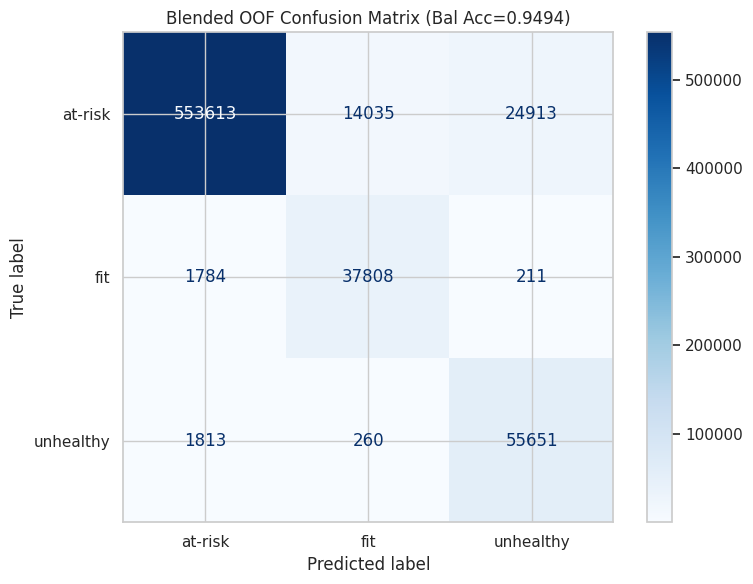


Classification Report (OOF Blended):
              precision    recall  f1-score   support

     at-risk       0.99      0.93      0.96    592561
         fit       0.73      0.95      0.82     39803
   unhealthy       0.69      0.96      0.80     57724

    accuracy                           0.94    690088
   macro avg       0.80      0.95      0.86    690088
weighted avg       0.95      0.94      0.94    690088


Per-class recall (balanced accuracy = mean of these):
  at-risk: 0.93427 (n=592561)
  fit: 0.94988 (n=39803)
  unhealthy: 0.96409 (n=57724)


In [7]:
# Confusion matrix for the blended model
blended_oof_proba = best_weight * lgb_oof_proba + (1 - best_weight) * cb_oof_proba
blended_oof_preds = np.argmax(blended_oof_proba, axis=1)

cm = confusion_matrix(y, blended_oof_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Blended OOF Confusion Matrix (Bal Acc={best_bal_acc:.4f})')
plt.tight_layout()
plt.show()

print("\nClassification Report (OOF Blended):")
print(classification_report(y, blended_oof_preds, target_names=CLASS_ORDER))

# Per-class recall (this is what balanced accuracy measures)
print("\nPer-class recall (balanced accuracy = mean of these):")
for i, cls in enumerate(CLASS_ORDER):
    mask = y == i
    recall = (blended_oof_preds[mask] == i).mean()
    print(f"  {cls}: {recall:.5f} (n={mask.sum()})")

## 8) Submission

In [8]:
# Final blended test predictions
final_test_proba = best_weight * lgb_test_proba + (1 - best_weight) * cb_test_proba
test_preds_class = np.argmax(final_test_proba, axis=1)
test_labels = le_target.inverse_transform(test_preds_class)

submission = sample_sub.copy()
submission[TARGET] = test_labels

# Validate submission format
assert submission.shape[0] == sample_sub.shape[0], "Row count mismatch!"
assert list(submission.columns) == list(sample_sub.columns), "Column mismatch!"
assert submission[TARGET].isna().sum() == 0, "NaN predictions!"

# Save
submission.to_csv(os.path.join(output_dir, "submission.csv"), index=False)

print("=" * 60)
print("SUBMISSION READY (V2 - Balanced Accuracy Optimized)")
print(f"  File: {output_dir}/submission.csv")
print(f"  Shape: {submission.shape}")
print(f"  Blend: LGB={best_weight:.2f}, CB={1-best_weight:.2f}")
print(f"  OOF Balanced Accuracy: {best_bal_acc:.5f}")
print(f"  LGB alone bal acc:     {balanced_accuracy_score(y, np.argmax(lgb_oof_proba, axis=1)):.5f}")
print(f"  CB alone bal acc:      {balanced_accuracy_score(y, np.argmax(cb_oof_proba, axis=1)):.5f}")
print("=" * 60)
print("\nPrediction distribution:")
print(submission[TARGET].value_counts())
print("\nSample rows:")
display(submission.head(10))

SUBMISSION READY (V2 - Balanced Accuracy Optimized)
  File: /kaggle/working/submission.csv
  Shape: (295753, 2)
  Blend: LGB=0.00, CB=1.00
  OOF Balanced Accuracy: 0.94941
  LGB alone bal acc:     0.94514
  CB alone bal acc:      0.94941

Prediction distribution:
health_condition
at-risk      239394
unhealthy     34398
fit           21961
Name: count, dtype: int64

Sample rows:


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
5,690093,fit
6,690094,at-risk
7,690095,at-risk
8,690096,at-risk
9,690097,at-risk
